# Minho Fatigue Dataset — Preprocessing & Exploratory Analysis


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal

In [ ]:
# ── Recording constants ───────────────────────────────────────────────────────
FS           = 1259          # Hz — sampling frequency
WINDOW_SAMP  = 512           # samples per window  (~407 ms)
STEP_SAMP    = 128           # hop size in samples (~102 ms)

In [ ]:
# Bandpass filter parameters
BP_LOW   = 20    # Hz  — removes DC and slow movement artefacts
BP_HIGH  = 450   # Hz  — removes high-frequency noise above MUAPs range
BP_ORDER = 4     # 4th-order Butterworth

## Dataset metadata (who are the subjects?)

In [ ]:
# load and tidy the metadata spreadsheet

meta = pd.read_excel('Metadata.xlsx')
meta.columns = ['Subject', 'Weight_kg', 'Height_cm', 'Age_years',
                'Gender', 'BMI', '_drop', 'Exercise_habits',
                'Workouts_per_week', 'Coffee_today']
meta = meta.drop(columns=['_drop']).dropna(subset=['Subject'])
meta['Subject'] = meta['Subject'].astype(int)
meta = meta.set_index('Subject')

meta

,Weight_kg,Height_cm,Age_years,Gender,BMI,Exercise_habits,Workouts_per_week,Coffee_today
Subject,,,,,,,,
1,63.5,170,27,F,21.972318,Yes,3,Yes
2,46.8,154,23,F,19.733513,Yes,2,Yes
3,83,184,22,M,24.515595,Yes,4,Yes
4,57,167,23,F,20.438166,Yes,6,Yes
5,68,174,33,M,22.460034,Yes,2,Yes
6,77,177,24,M,24.577867,Yes,5,Yes
7,84,188,20,M,23.76641,Yes,2,No
8,58,174,27,M,19.157088,Yes,2,Yes
9,65,162,23,F,24.767566,Yes,4,Yes


### Summary Statistics

In [ ]:
print('Demographics')
meta[['Weight_kg', 'Height_cm', 'Age_years', 'BMI']].describe().round(2)

Demographics


,Weight_kg,Height_cm,Age_years,BMI
count,13.0,13,13,13.00
unique,13.0,11,7,13.00
top,63.5,174,23,21.97
freq,1.0,2,3,1.00


In [ ]:
print('Gender breakdown:')
meta['Gender'].value_counts()

Gender breakdown:


Gender
M    8
F    5
Name: count, dtype: int64

In [ ]:
print('Exercise habits (Yes/No):')
meta['Exercise_habits'].value_counts()

Exercise habits (Yes/No):


Exercise_habits
Yes    10
No      3
Name: count, dtype: int64

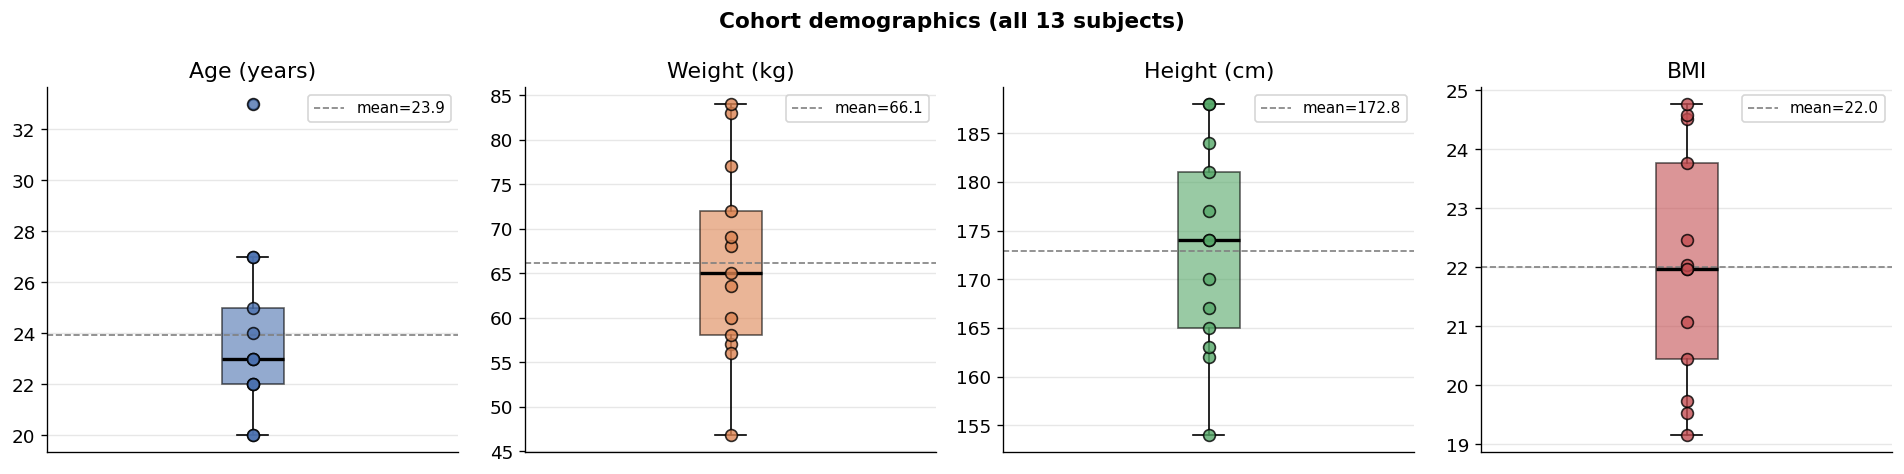

In [ ]:
# Visualise cohort demographics
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Cohort demographics (all 13 subjects)', fontsize=13, fontweight='bold')

cols = ['Age_years', 'Weight_kg', 'Height_cm', 'BMI']
labels = ['Age (years)', 'Weight (kg)', 'Height (cm)', 'BMI']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, lab, col_color in zip(axes, cols, labels, colors):
    values = meta[col].dropna()
    ax.boxplot(values, patch_artist=True,
               boxprops=dict(facecolor=col_color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    # Overlay individual points (strip)
    ax.scatter([1]*len(values), values, color=col_color,
               edgecolors='black', zorder=3, s=50, alpha=0.8)
    ax.set_title(lab)
    ax.set_xticks([])
    mean_val = values.mean()
    ax.axhline(mean_val, color='gray', linestyle='--', linewidth=1, label=f'mean={mean_val:.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## Experimental protocol

In [ ]:
# Protocol summary
protocol_info = {
    'Trial': list(range(1, 13)),
    'Movement_type': ['Uni-articular']*8 + ['Complex']*4,
    'Prime_mover': [
        'R Deltoid Anterior', 'L Deltoid Anterior',
        'R Deltoid Posterior', 'L Deltoid Posterior',
        'R Biceps Brachii', 'L Biceps Brachii',
        'R Deltoid Medius', 'L Deltoid Medius',
        'R Deltoid Anterior (complex)', 'L Deltoid Anterior (complex)',
        'R Deltoid Posterior (complex)', 'L Deltoid Posterior (complex)',
    ]
}
protocol_df = pd.DataFrame(protocol_info).set_index('Trial')
print('Protocol — each trial is separated by 5-minute rest')
print(f'Sampling frequency: 1259 Hz (sEMG)')
print()
protocol_df

Protocol — each trial is separated by 5-minute rest
Sampling frequency: 1259 Hz (sEMG)



,Movement_type,Prime_mover
Trial,,
1,Uni-articular,R Deltoid Anterior
2,Uni-articular,L Deltoid Anterior
3,Uni-articular,R Deltoid Posterior
4,Uni-articular,L Deltoid Posterior
5,Uni-articular,R Biceps Brachii
6,Uni-articular,L Biceps Brachii
7,Uni-articular,R Deltoid Medius
8,Uni-articular,L Deltoid Medius
9,Complex,R Deltoid Anterior (complex)


## Load raw data - Subject 5, Trials 1 & 4

Each trial CSV has **8 columns**: alternating time-axis (`X [s]`) and EMG voltage (`[V]`) columns, one pair per electrode.

In [ ]:
# SUBJECT = 5
SUBJECT_DIR = os.path.join('sEMG_data/subject_5')

def load_trial(subject_dir, trial_num):
    """
    Load one trial CSV and return a tidy dictionary:
      {'time': array, 'channels': {channel_name: voltage_array}}

    The CSV alternates time/voltage columns so we pair them up.
    """
    path = os.path.join(SUBJECT_DIR, f'trial_{trial_num}.csv')
    df = pd.read_csv(path)

    # Separate time columns (contain 'X [s]') from EMG voltage columns
    time_cols = [c for c in df.columns if 'X [s]' in c]
    emg_cols  = [c for c in df.columns if '[V]' in c]

    # Use the first time column as the shared time axis
    # (all channels share the same fs so time arrays are identical)
    time = df[time_cols[0]].values

    channels = {col: df[col].values for col in emg_cols}

    return {'time': time, 'channels': channels, 'n_samples': len(time)}


trial1 = load_trial(SUBJECT_DIR, trial_num=1)
trial4 = load_trial(SUBJECT_DIR, trial_num=4)

print(f'Trial 1 — {trial1["n_samples"]:,} samples ({trial1["time"][-1]:.1f} s)')
print(f'Channels: {list(trial1["channels"].keys())}')
print()
print(f'Trial 4 — {trial2["n_samples"]:,} samples ({trial4["time"][-1]:.1f} s)')
print(f'Channels: {list(trial2["channels"].keys())}')

Trial 1 — 275,338 samples  (218.6 s)
Channels: ['R BICEPS BRACHII: EMG 1 [V]', 'R DELTOID ANTERIOR: EMG 2 [V]', 'R DELTOID MEDIUS: EMG 6 [V]', 'R DELTOID POSTERIOR: EMG 7 [V]']

Trial 4 — 218,044 samples  (173.2 s)
Channels: ['L DELTOID ANTERIOR: EMG 3 [V]', 'L BICEPS BRACHII: EMG 4 [V]', 'L DELTOID POSTERIOR: EMG 5 [V]', 'L DELTOID MEDIUS: EMG 8 [V]']


---

## Data quality checks

Before filtering, we will check for:
- **Missing / NaN values**
- **Flat-line segments** (electrode disconnections)
- **Amplitude outliers** (amplifier saturation)
- **Sampling rate consistency** (uniform time steps)

In [ ]:
def quality_report(trial_data, trial_name):
    """
    Print a quality report for one trial.
    Returns a summary DataFrame.
    """
    time = trial_data['time']
    rows = []

    # Check time-step regularity
    dt = np.diff(time)
    expected_dt = 1.0 / FS
    dt_ok = np.allclose(dt, expected_dt, rtol=1e-3)

    print(f'Quality report: {trial_name}')
    print(f'Duration: {time[-1]:.2f} s')
    print(f'Samples: {len(time):,}')
    print(f'Implied fs: {1/dt.mean():.2f} Hz  (expected {FS} Hz)')
    print(f'Time-step OK?: {dt_ok}')

    for ch_name, sig in trial_data['channels'].items():
        n_nan = int(np.isnan(sig).sum())
        n_inf = int(np.isinf(sig).sum())
        n_flat = int(np.sum(np.diff(sig) == 0))  # consecutive identical values
        p_flat = 100 * n_flat / len(sig)
        amp_max = np.nanmax(np.abs(sig)) * 1000    # convert V → mV
        amp_rms = np.sqrt(np.nanmean(sig**2)) * 1000

        rows.append({
            'Channel' : ch_name.split(':')[0],  # keep short name
            'NaN': n_nan,
            'Inf' : n_inf,
            'Flat (%)': round(p_flat, 2),
            'Peak (mV)': round(amp_max, 4),
            'RMS (mV)': round(amp_rms, 4),
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    return df

In [ ]:
qr1 = quality_report(trial1, 'Trial 1 (right side)')

Quality report: Trial 1 (right side)
Duration: 218.65 s
Samples: 275,338
Implied fs: 1259.26 Hz  (expected 1259 Hz)
Time-step OK?: True
            Channel  NaN  Inf  Flat (%)  Peak (mV)  RMS (mV)
   R BICEPS BRACHII    0    0      0.29     0.7194    0.0700
 R DELTOID ANTERIOR    0    0      0.59     1.5581    0.1131
   R DELTOID MEDIUS    0    0      0.54     2.2350    0.1873
R DELTOID POSTERIOR    0    0      0.80     0.5300    0.0321


In [ ]:
qr2 = quality_report(trial4, 'Trial 4 (left side)')

Quality report: Trial 4 (left side)
Duration: 173.15 s
Samples: 218,044
Implied fs: 1259.26 Hz  (expected 1259 Hz)
Time-step OK?: True
            Channel  NaN  Inf  Flat (%)  Peak (mV)  RMS (mV)
 L DELTOID ANTERIOR    0    0      1.12     0.1968    0.0142
   L BICEPS BRACHII    0    0      0.82     0.7430    0.0176
L DELTOID POSTERIOR    0    0      0.53     1.7237    0.1630
   L DELTOID MEDIUS    0    0      0.61     1.3410    0.1096


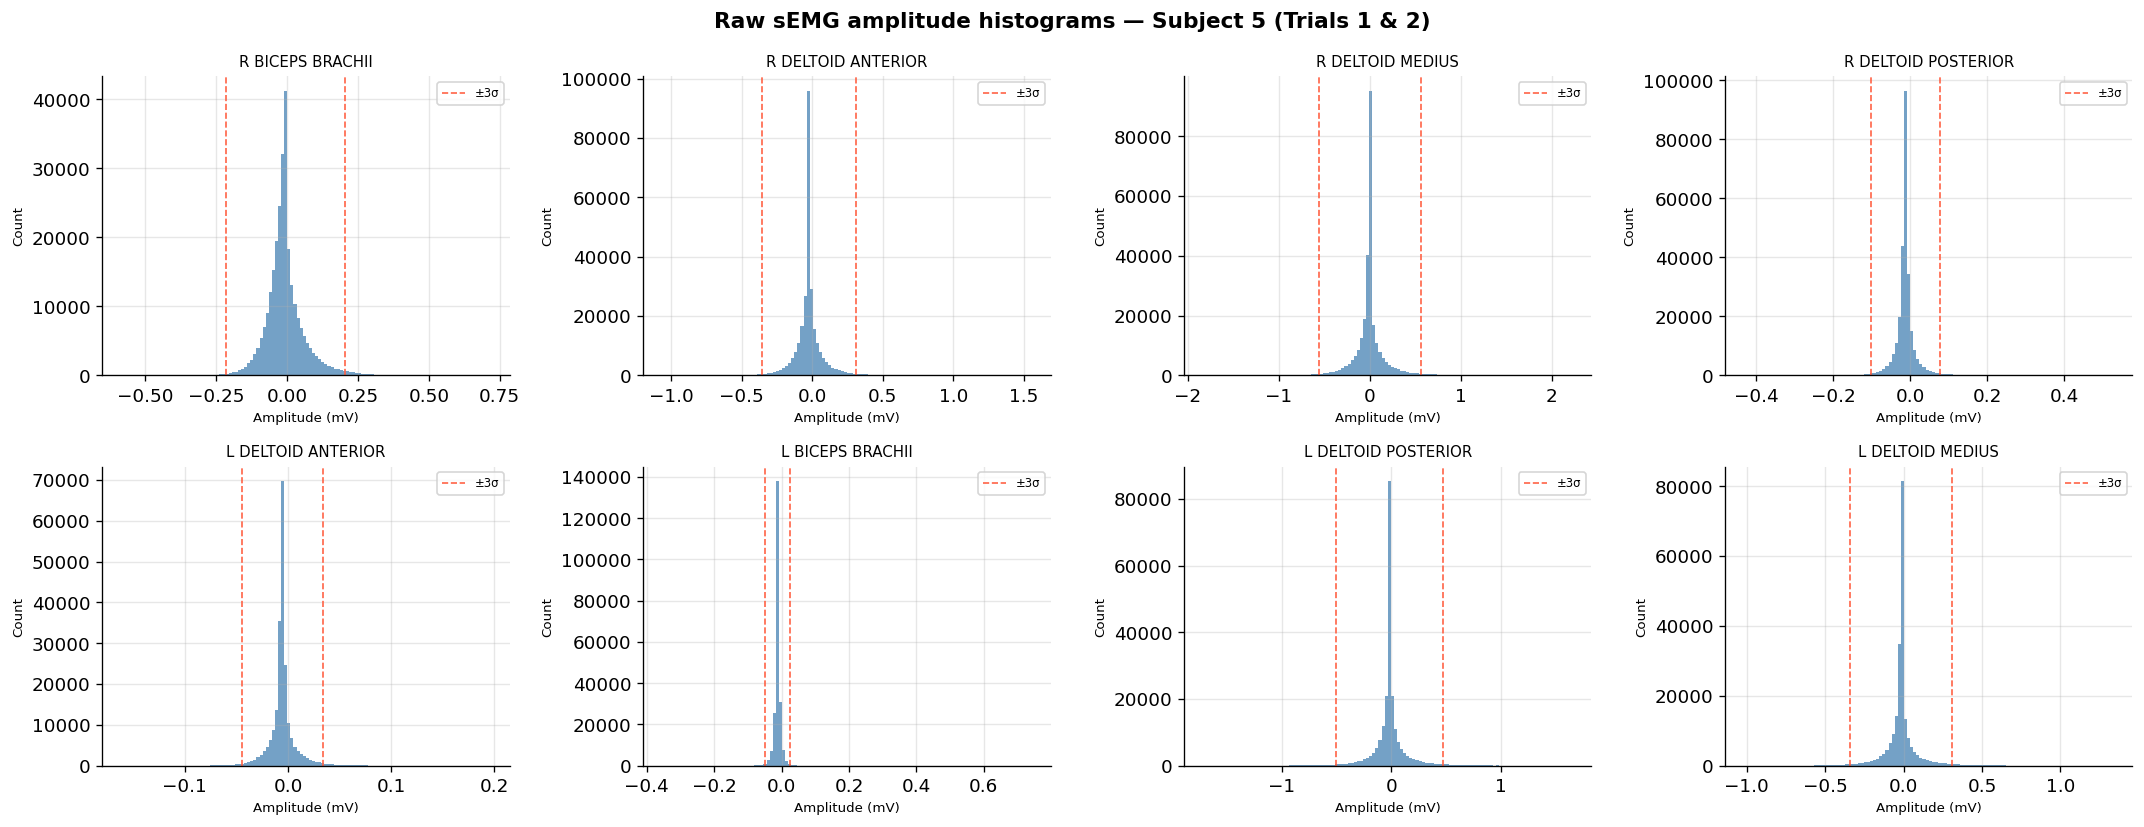

In [ ]:
# Visualise the raw amplitude distribution
all_channels = {**trial1['channels'], **trial2['channels']}

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Raw sEMG amplitude histograms — Subject 5 (Trials 1 & 2)',
             fontsize=13, fontweight='bold')

for ax, (ch, sig) in zip(axes.flat, all_channels.items()):
    sig_mV = sig * 1000  # V → mV
    ax.hist(sig_mV, bins=120, color='steelblue', alpha=0.75, edgecolor='none')
    # Mark ±3-sigma threshold
    mu, sd = np.nanmean(sig_mV), np.nanstd(sig_mV)
    ax.axvline(mu - 3*sd, color='tomato', linestyle='--', linewidth=1, label='±3σ')
    ax.axvline(mu + 3*sd, color='tomato', linestyle='--', linewidth=1)
    ax.set_title(ch.split(':')[0], fontsize=9)
    ax.set_xlabel('Amplitude (mV)', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---

## Bandpass filtering (20–450 Hz, 4th-order Butterworth)

| Band removed | What it contains |
|---|---|
| 0–20 Hz | DC offset, electrode movement, breathing artefacts |
| 450–629 Hz | High-frequency noise, aliasing residuals |
| **20–450 Hz** | **Motor unit action potentials (MUAPs)** — the signal we want |

`filtfilt` (zero-phase) is used so the filter does **not shift the signal in time**.

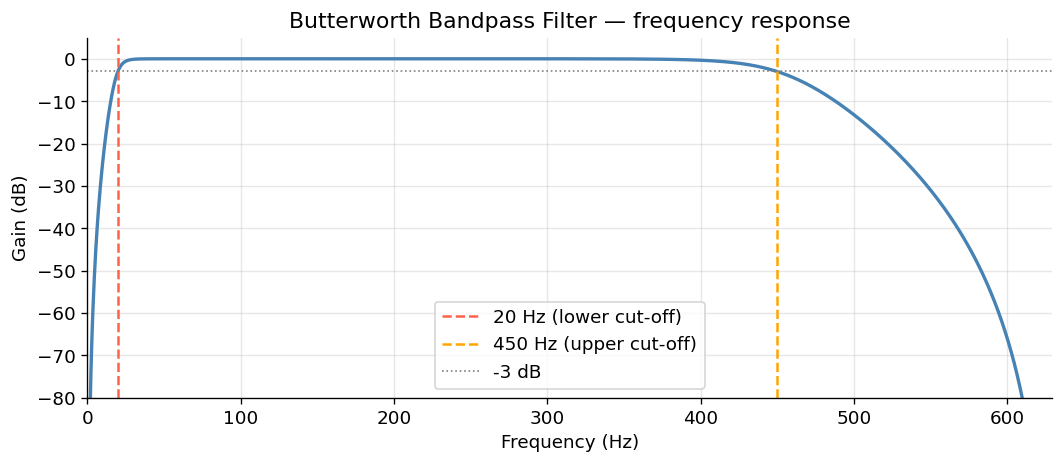

Filter order: 4
Pass-band : 20 – 450 Hz


In [ ]:
# Design the bandpass filter
b_bp, a_bp = scipy_signal.butter(
    BP_ORDER,
    [BP_LOW, BP_HIGH],
    btype='bandpass',
    fs=FS
)

# Visualise the filter frequency response
w, h = scipy_signal.freqz(b_bp, a_bp, worN=2048, fs=FS)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w, 20 * np.log10(np.abs(h)), color='steelblue', linewidth=2)
ax.axvline(BP_LOW,  color='tomato', linestyle='--', linewidth=1.5, label=f'{BP_LOW} Hz (lower cut-off)')
ax.axvline(BP_HIGH, color='orange', linestyle='--', linewidth=1.5, label=f'{BP_HIGH} Hz (upper cut-off)')
ax.axhline(-3, color='gray', linestyle=':', linewidth=1, label='-3 dB')
ax.set_xlim([0, FS/2])
ax.set_ylim([-80, 5])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Gain (dB)')
ax.set_title('Butterworth Bandpass Filter — frequency response')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Filter order: {BP_ORDER}')
print(f'Pass-band : {BP_LOW} – {BP_HIGH} Hz')

In [ ]:
def filter_trial(trial_data):
    """
    Apply zero-phase bandpass filter to all channels in a trial.
    Returns a new trial dictionary with filtered signals.
    """
    filtered = dict(trial_data)           # shallow copy of metadata
    filtered['channels'] = {}

    for ch_name, sig in trial_data['channels'].items():
        # Replace any NaN or Inf with 0 before filtering
        sig_clean = np.where(np.isfinite(sig), sig, 0.0)
        # Zero-phase Butterworth bandpass
        filtered['channels'][ch_name] = scipy_signal.filtfilt(b_bp, a_bp, sig_clean)

    return filtered


trial1_filt = filter_trial(trial1)
trial4_filt = filter_trial(trial4)

print('Filtering complete.')

Filtering complete.


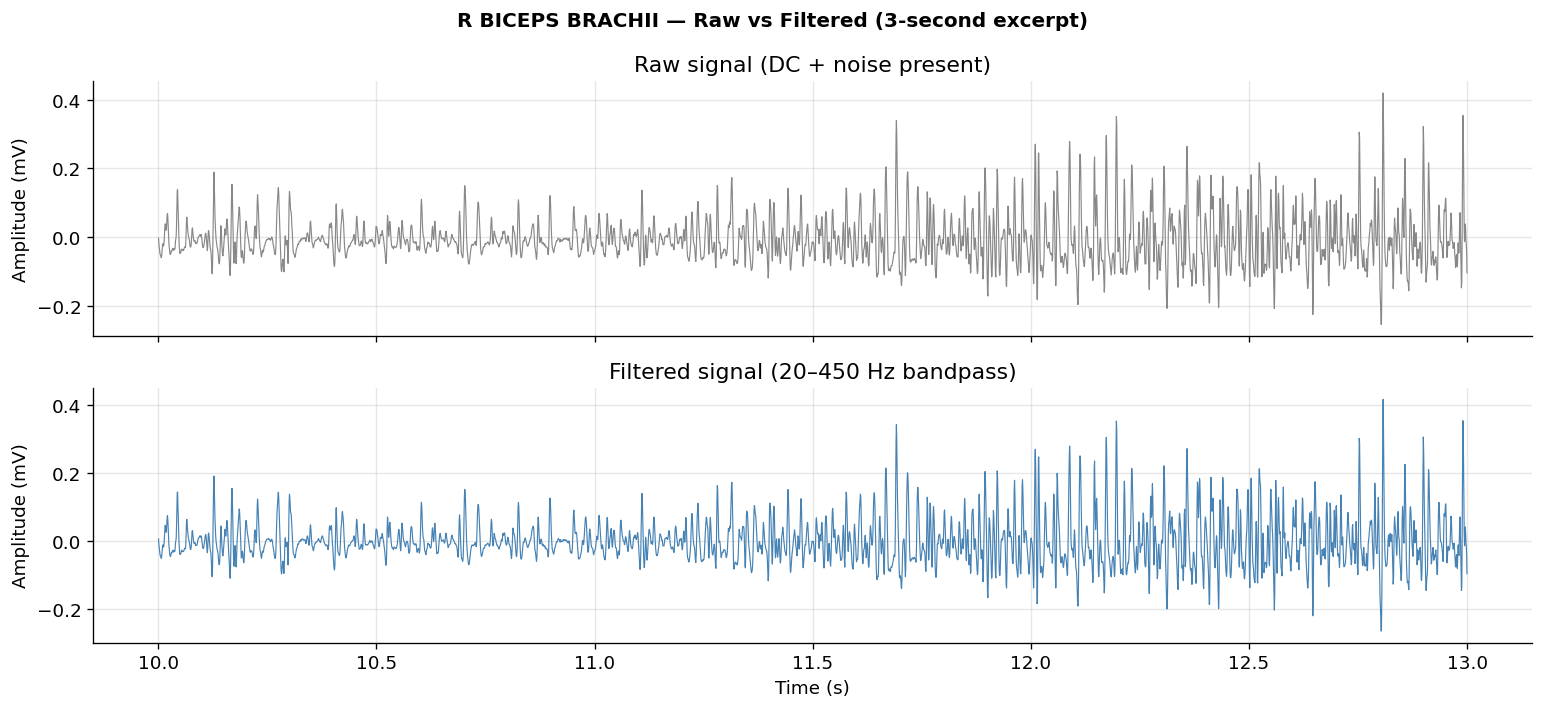

In [ ]:
# Side-by-side comparison: raw vs filtered for one channel
example_ch = 'R BICEPS BRACHII: EMG 1 [V]'
time   = trial1['time']
raw_v  = trial1['channels'][example_ch]
filt_v = trial1_filt['channels'][example_ch]

# Show a 3-second window so individual MUAPs are visible
t_start, t_end = 10.0, 13.0
mask = (time >= t_start) & (time <= t_end)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle(f'{example_ch.split(":")[0]} — Raw vs Filtered (3-second excerpt)',
             fontsize=12, fontweight='bold')

axes[0].plot(time[mask], raw_v[mask]*1000, color='#888888', linewidth=0.7)
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_title('Raw signal (DC + noise present)')

axes[1].plot(time[mask], filt_v[mask]*1000, color='steelblue', linewidth=0.7)
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Filtered signal (20–450 Hz bandpass)')

plt.tight_layout()
plt.show()

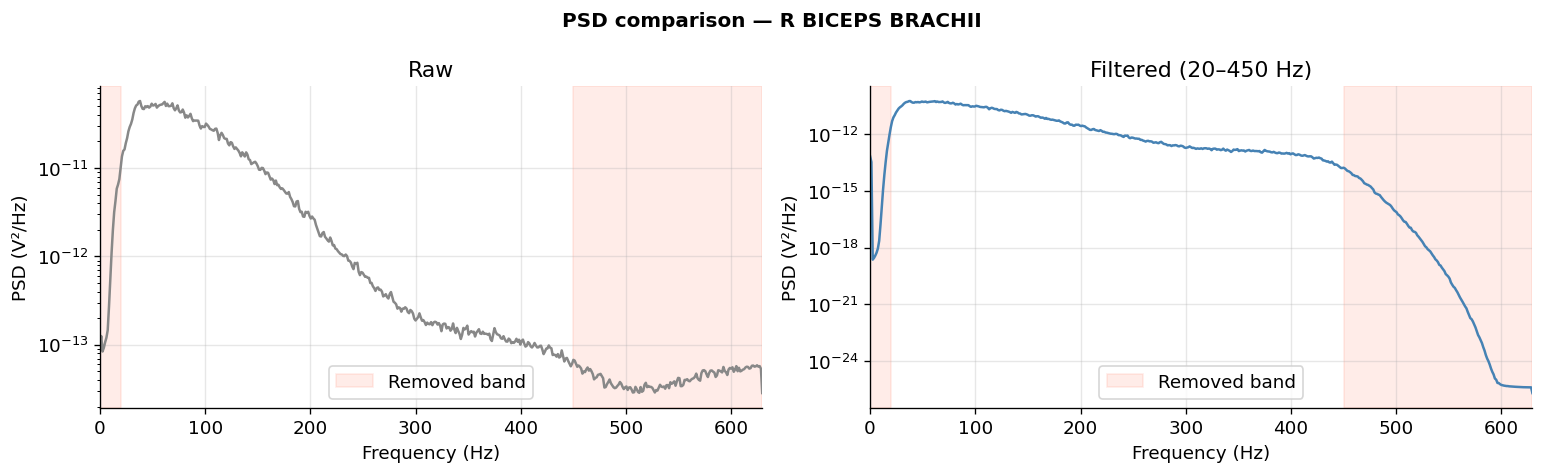

In [ ]:
# Power spectral density: before and after filtering
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'PSD comparison — {example_ch.split(":")[0]}',
             fontsize=12, fontweight='bold')

for ax, sig, title, col in zip(
    axes,
    [raw_v, filt_v],
    ['Raw', 'Filtered (20–450 Hz)'],
    ['#888888', 'steelblue']
):
    freqs, psd = scipy_signal.welch(sig, fs=FS, nperseg=1024)
    ax.semilogy(freqs, psd, color=col, linewidth=1.5)
    ax.axvspan(0, BP_LOW, alpha=0.12, color='tomato', label='Removed band')
    ax.axvspan(BP_HIGH, FS/2, alpha=0.12, color='tomato')
    ax.set_xlim([0, FS/2])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (V²/Hz)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

---

## Full filtered signal overview, both trials

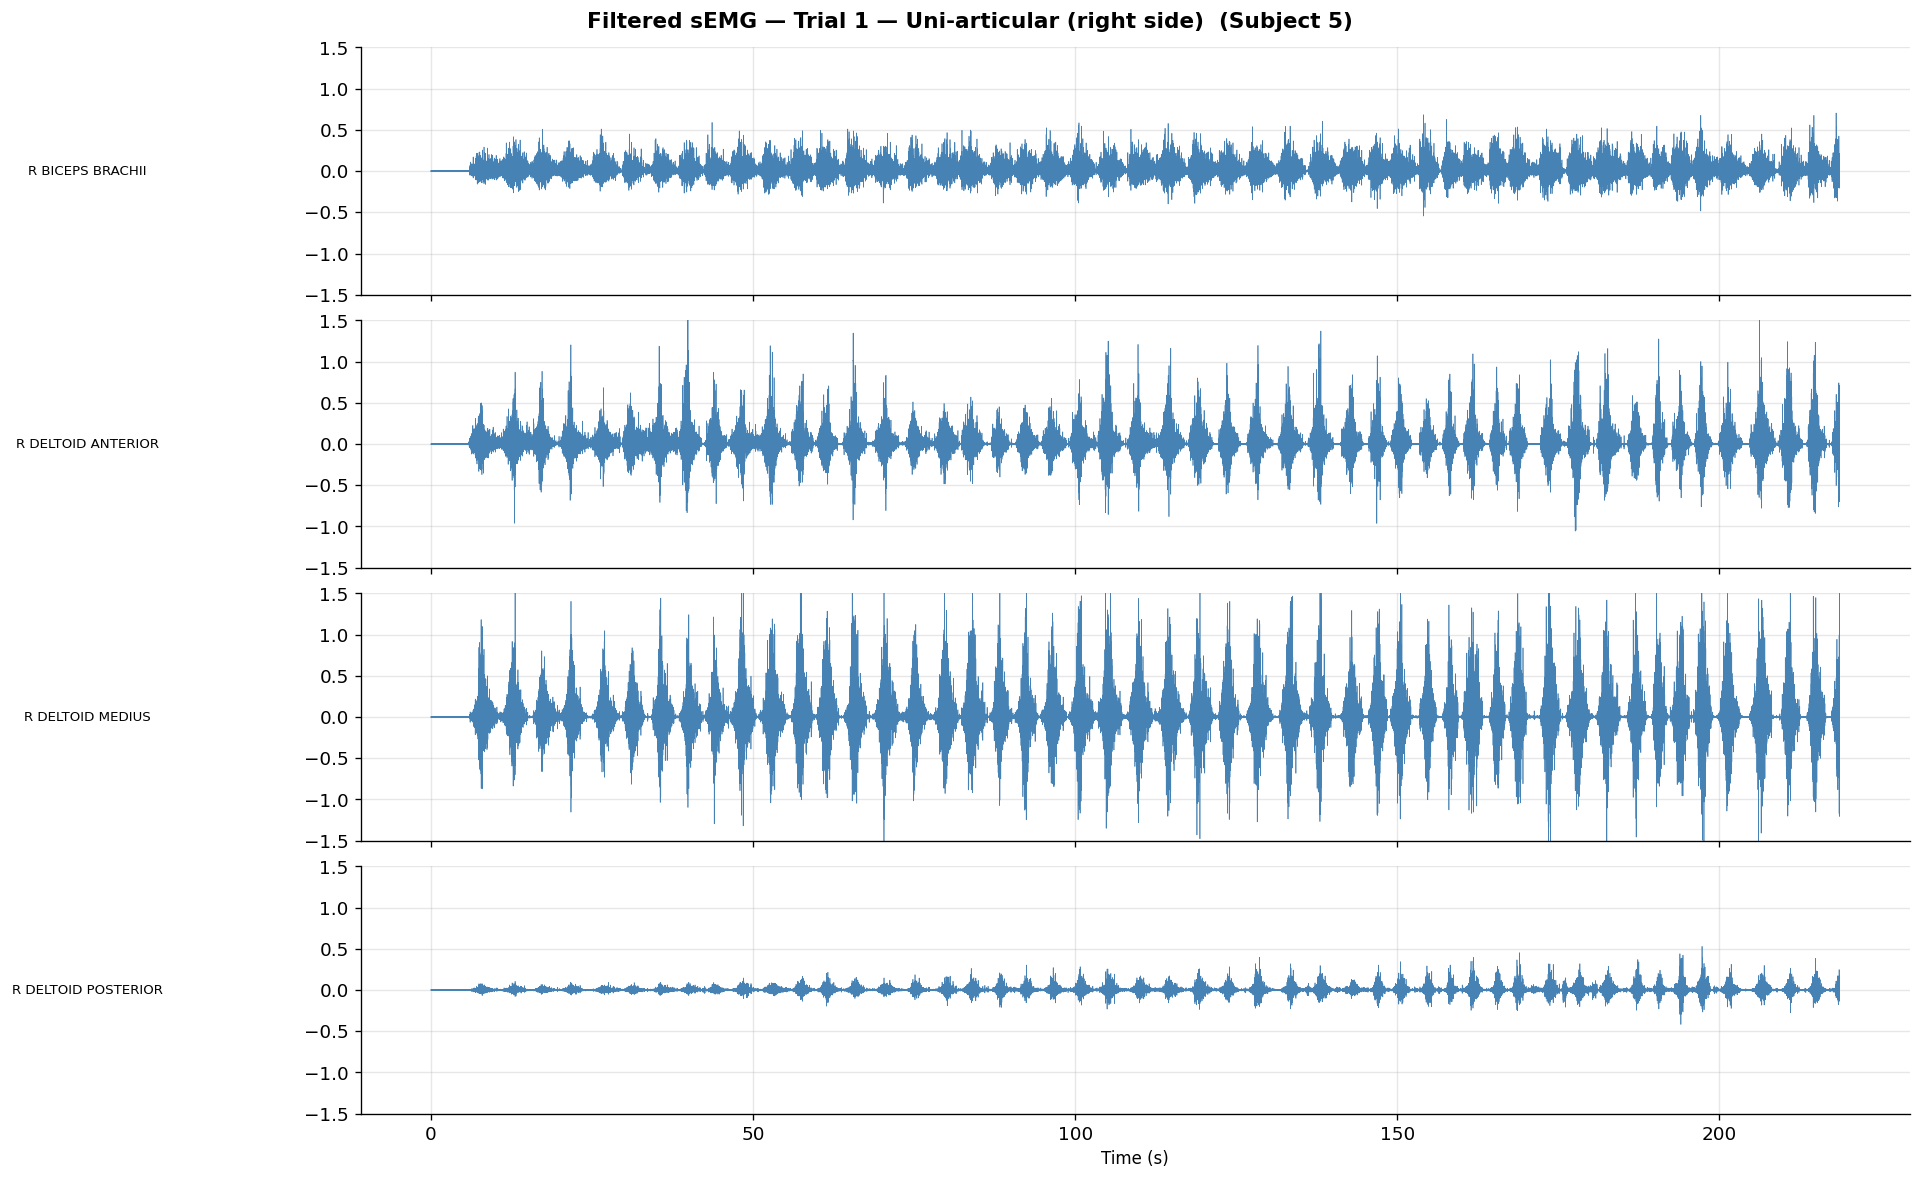

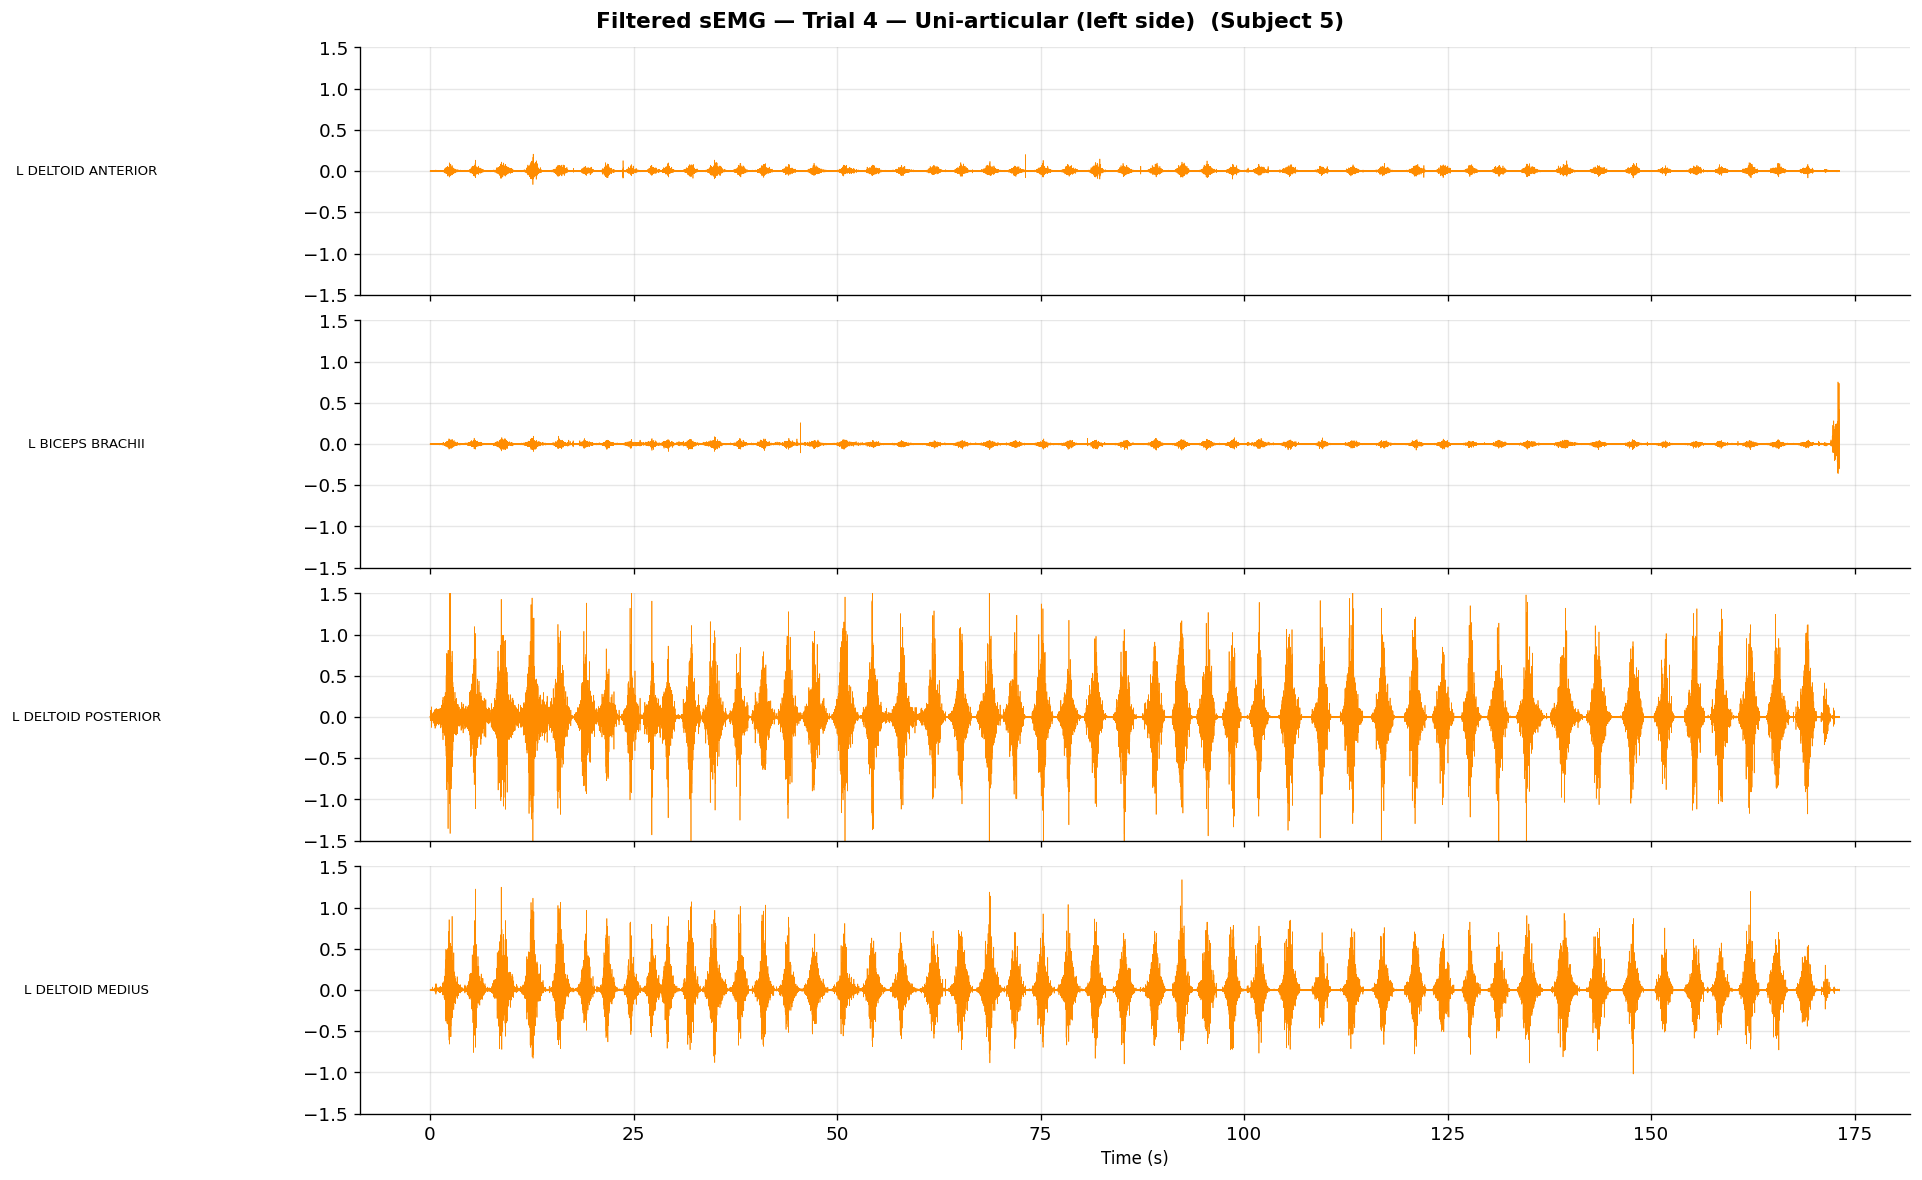

In [ ]:
def plot_full_trial(trial_filt, trial_name, color='steelblue'):
    """
    Plot all filtered channels in one figure (full duration).
    Channels are stacked vertically and offset for readability.
    """
    time     = trial_filt['time']
    channels = trial_filt['channels']
    n_ch     = len(channels)

    fig, axes = plt.subplots(n_ch, 1, figsize=(16, 2.5 * n_ch), sharex=True)
    fig.suptitle(f'Filtered sEMG — {trial_name}  (Subject 5)',
                 fontsize=13, fontweight='bold')

    for ax, (ch_name, sig) in zip(axes, channels.items()):
        ax.plot(time, sig * 1000, linewidth=0.4, color=color)
        short_name = ch_name.split(':')[0]
        ax.set_ylabel(short_name, fontsize=8, rotation=0,
                      labelpad=130, verticalalignment='center')
        ax.set_ylim(-1.5, 1.5)  # mV range typical for surface EMG

    axes[-1].set_xlabel('Time (s)', fontsize=10)
    plt.tight_layout()
    plt.show()


plot_full_trial(trial1_filt, 'Trial 1 — Uni-articular (right side)', color='steelblue')
plot_full_trial(trial4_filt, 'Trial 4 — Uni-articular (left side)',  color='darkorange')

---

## 7. Sliding-window feature extraction

### Physics proxies extracted from each window

| Feature | Formula | Physical meaning |
|---|---|---|
| **RMS** | $\sqrt{\frac{1}{N}\sum x_i^2}$ | Signal power / muscle force proxy |
| **MDF** | $f$ s.t. $\sum_{0}^{f} S(f) = \frac{1}{2}\sum_{all} S(f)$ | Spectral centre — shifts left with fatigue |

> **Window parameters:**  
> - Size: 512 samples = **407 ms** (captures enough MUAP cycles for stable PSD)  
> - Step: 128 samples = **102 ms** (75 % overlap — smooth time series of features)

In [ ]:
def compute_rms(window):
    """
    Root Mean Square amplitude of a signal window.
    Proportional to muscle activation / force production.
    """
    return np.sqrt(np.mean(window ** 2))


def compute_mdf(window, fs):
    """
    Median Frequency (MDF) of a window's Welch PSD.

    MDF is the frequency that splits the power spectrum into two
    halves of equal area.  It decreases with muscle fatigue because
    slow-twitch fibres (lower conduction velocity) are recruited more
    as fast-twitch fibres fatigue.

    Parameters
    ----------
    window : 1-D array of filtered EMG samples
    fs     : sampling frequency in Hz

    Returns
    -------
    mdf : float  (Hz)
    """
    # Welch PSD — robust to noise because it averages periodograms
    freqs, psd = scipy_signal.welch(window, fs=fs, nperseg=len(window))

    # Restrict to physiological band already captured by bandpass
    band_mask = (freqs >= BP_LOW) & (freqs <= BP_HIGH)
    freqs_b   = freqs[band_mask]
    psd_b     = psd[band_mask]

    if psd_b.sum() == 0:
        return np.nan  # guard against silent channels

    # Cumulative power → find 50 % point
    cumpower  = np.cumsum(psd_b)
    half_power = cumpower[-1] / 2.0
    mdf_idx   = np.searchsorted(cumpower, half_power)
    mdf_idx   = min(mdf_idx, len(freqs_b) - 1)  # boundary safety

    return freqs_b[mdf_idx]


def sliding_window_features(trial_filt, window_samp=WINDOW_SAMP, step_samp=STEP_SAMP, fs=FS):
    """
    Slide a window over every channel and compute RMS + MDF per window.

    Returns
    -------
    features : dict  {channel_name: {'time': array, 'rms': array, 'mdf': array}}
    """
    time = trial_filt['time']
    n    = len(time)
    features = {}

    # Window centre times
    starts       = np.arange(0, n - window_samp + 1, step_samp)
    center_times = time[starts + window_samp // 2]

    for ch_name, sig in trial_filt['channels'].items():
        rms_vals = np.array([compute_rms(sig[s: s + window_samp]) for s in starts])
        mdf_vals = np.array([compute_mdf(sig[s: s + window_samp], fs) for s in starts])

        features[ch_name] = {
            'time': center_times,
            'rms' : rms_vals * 1000,   # V → mV
            'mdf' : mdf_vals,          # Hz
        }

    return features

In [ ]:
feat1 = sliding_window_features(trial1_filt)
print("Features for trial 1")
print(f'{len(list(feat1.values())[0]["time"]):,} windows per channel')

Features for trial 1
2,148 windows per channel


In [ ]:
feat4 = sliding_window_features(trial4_filt)
print("Features for trial 4")
print(f'{len(list(feat4.values())[0]["time"]):,} windows per channel')

Features for trial 4
1,700 windows per channel


---

## Feature Visualisation, RMS & MDF over time

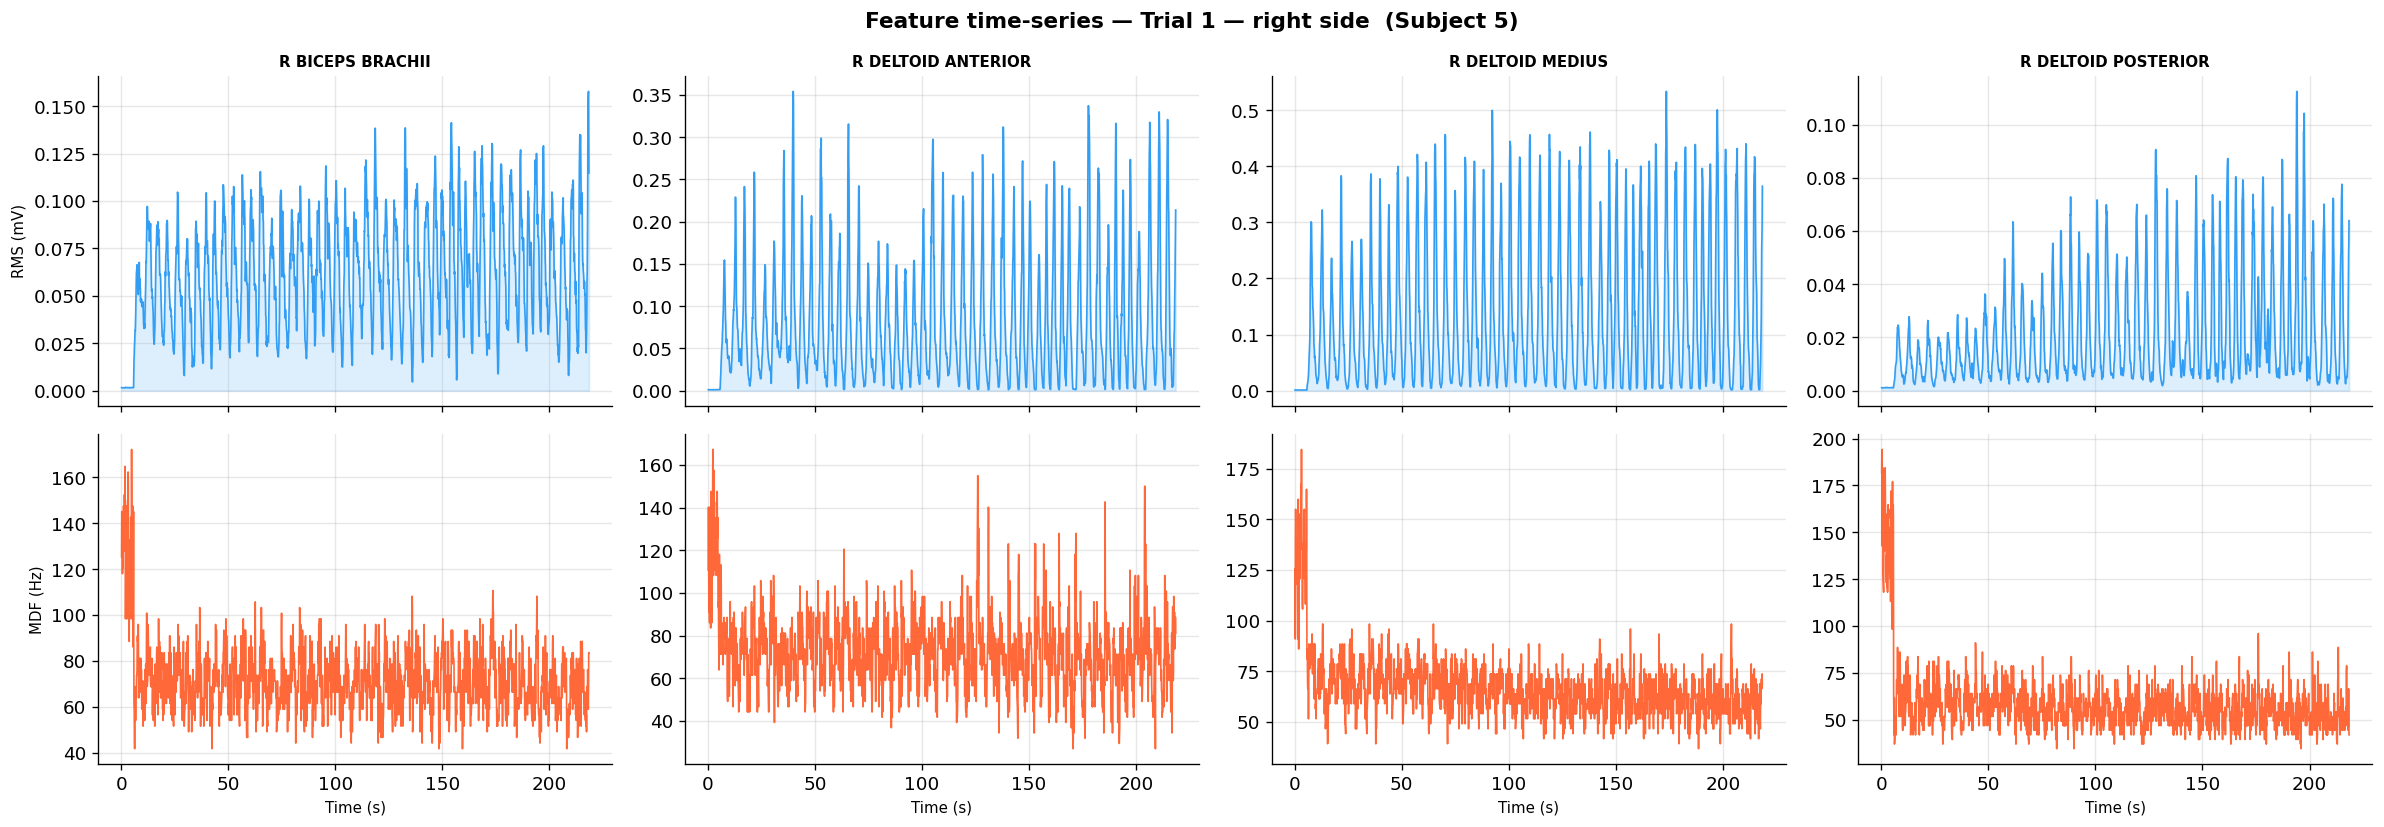

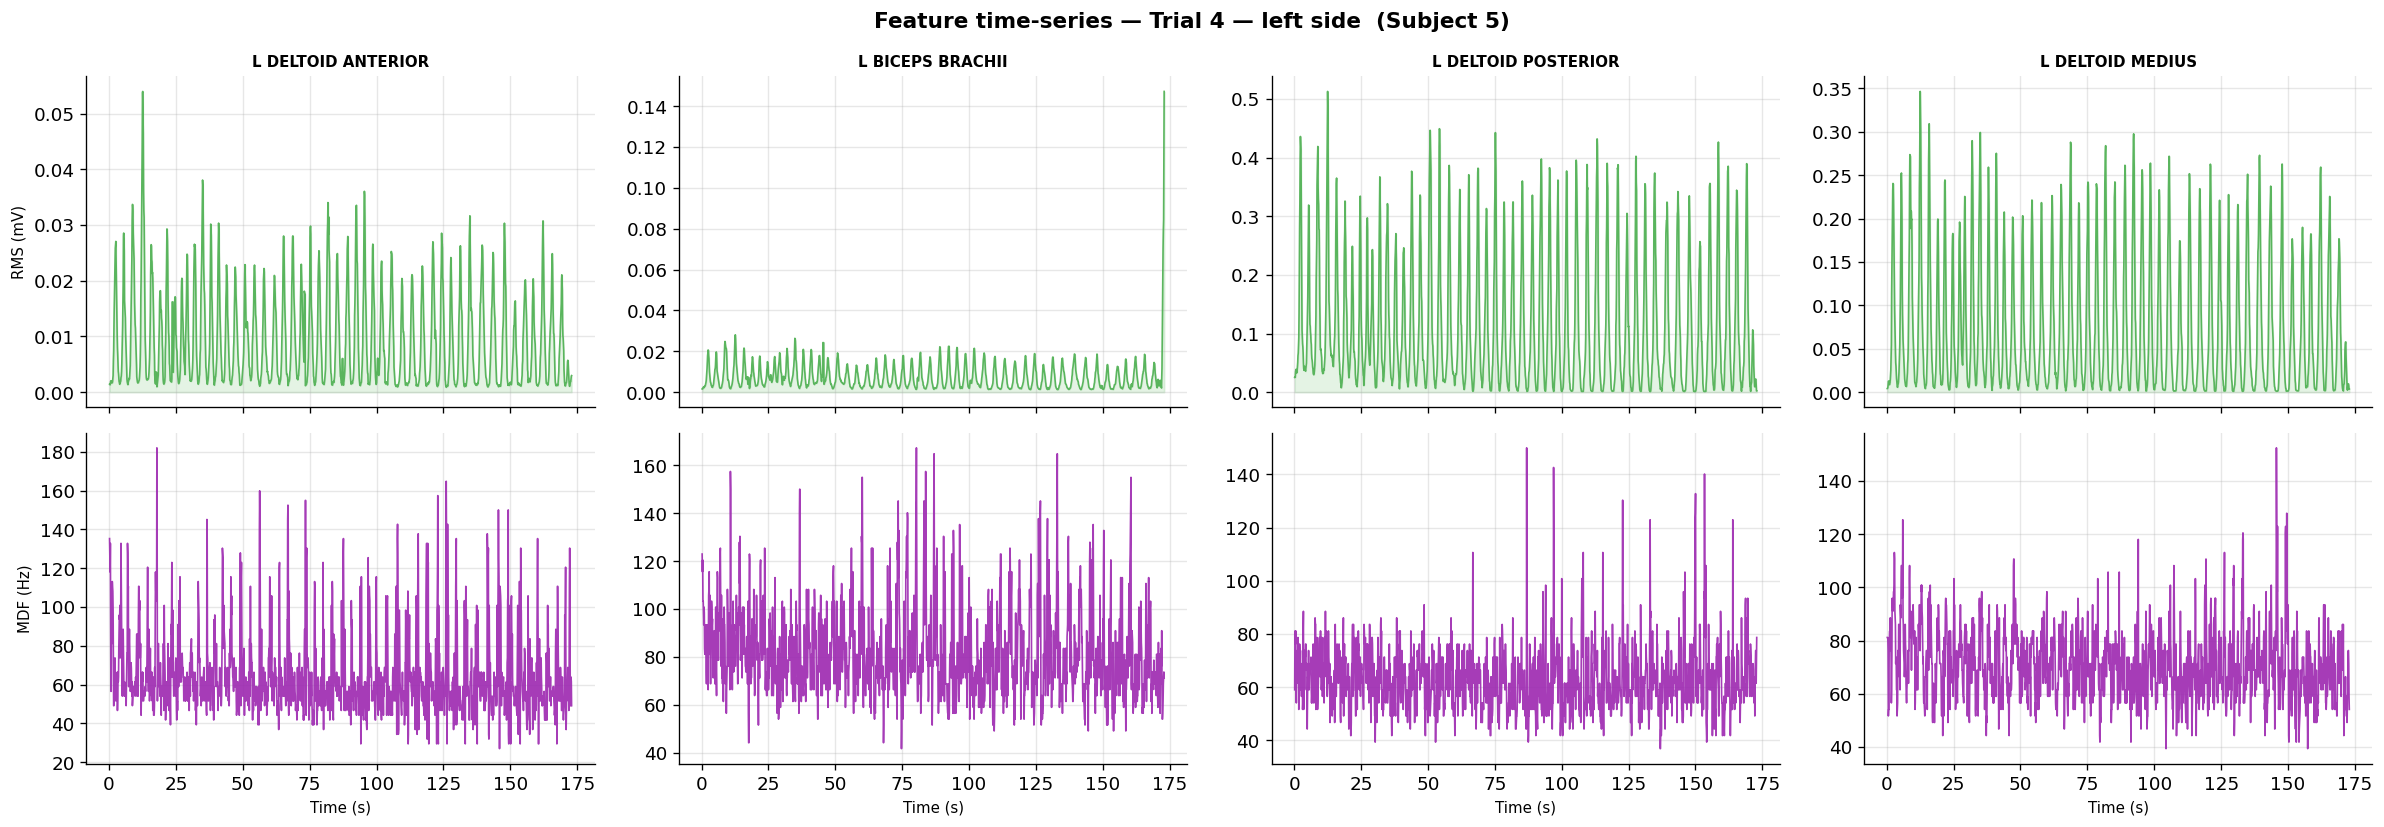

In [ ]:
def plot_features(features, trial_name, rms_color='#2196F3', mdf_color='#FF5722'):
    """
    For each channel, plot RMS and MDF as a function of time.
    Two subplots per channel (top=RMS, bottom=MDF), one column per channel.
    """
    channels = list(features.keys())
    n_ch = len(channels)

    fig, axes = plt.subplots(2, n_ch, figsize=(5 * n_ch, 7), sharex='col')
    fig.suptitle(f'Feature time-series — {trial_name}  (Subject 5)',
                 fontsize=13, fontweight='bold')

    for col_idx, ch in enumerate(channels):
        t   = features[ch]['time']
        rms = features[ch]['rms']
        mdf = features[ch]['mdf']
        short = ch.split(':')[0]

        # RMS row
        ax_rms = axes[0, col_idx]
        ax_rms.plot(t, rms, color=rms_color, linewidth=1.0, alpha=0.9)
        ax_rms.fill_between(t, rms, alpha=0.15, color=rms_color)
        ax_rms.set_title(short, fontsize=9, fontweight='bold')
        if col_idx == 0:
            ax_rms.set_ylabel('RMS (mV)', fontsize=9)

        # MDF row
        ax_mdf = axes[1, col_idx]
        ax_mdf.plot(t, mdf, color=mdf_color, linewidth=1.0, alpha=0.9)
        ax_mdf.set_xlabel('Time (s)', fontsize=9)
        if col_idx == 0:
            ax_mdf.set_ylabel('MDF (Hz)', fontsize=9)

    # Row labels
    axes[0, 0].annotate('RMS', xy=(0, 0.5), xytext=(-0.35, 0.5),
                        textcoords='axes fraction', fontsize=10,
                        fontweight='bold', va='center', color=rms_color,
                        rotation=90)
    axes[1, 0].annotate('MDF', xy=(0, 0.5), xytext=(-0.35, 0.5),
                        textcoords='axes fraction', fontsize=10,
                        fontweight='bold', va='center', color=mdf_color,
                        rotation=90)

    plt.tight_layout()
    plt.show()


plot_features(feat1, 'Trial 1 — right side')
plot_features(feat4, 'Trial 4 — left side', rms_color='#4CAF50', mdf_color='#9C27B0')

---

## Descriptive statistics of extracted features

In [ ]:
def feature_stats_table(features, trial_name):
    """
    Compute mean, median, std, IQR, min, max for RMS and MDF
    across all windows for each channel.
    """
    rows = []
    for ch, d in features.items():
        short = ch.split(':')[0]
        for feat_name, vals in [('RMS (mV)', d['rms']), ('MDF (Hz)', d['mdf'])]:
            clean = vals[np.isfinite(vals)]
            q25, q75 = np.percentile(clean, [25, 75])
            rows.append({
                'Trial': trial_name,
                'Channel': short,
                'Feature': feat_name,
                'Mean': round(clean.mean(), 4),
                'Median': round(np.median(clean), 4),
                'Std': round(clean.std(), 4),
                'IQR': round(q75 - q25, 4),
                'Min': round(clean.min(), 4),
                'Max': round(clean.max(), 4),
            })
    return pd.DataFrame(rows)


stats1 = feature_stats_table(feat1, 'Trial 1')
stats4 = feature_stats_table(feat4, 'Trial 4')
stats_all = pd.concat([stats1, stats4], ignore_index=True)

print('Descriptive statistics of RMS and MDF features')
pd.set_option('display.float_format', '{:.4f}'.format)
stats_all

Descriptive statistics of RMS and MDF features


,Trial,Channel,Feature,Mean,Median,Std,IQR,Min,Max
0,Trial 1,R BICEPS BRACHII,RMS (mV),0.0619,0.0614,0.0302,0.0480,0.0014,0.1578
1,Trial 1,R BICEPS BRACHII,MDF (Hz),71.8085,71.3105,15.0534,17.2129,41.8027,172.1289
2,Trial 1,R DELTOID ANTERIOR,RMS (mV),0.0806,0.0556,0.0746,0.0966,0.0010,0.3543
3,Trial 1,R DELTOID ANTERIOR,MDF (Hz),72.4656,71.3105,18.0695,19.6719,27.0488,167.2109
4,Trial 1,R DELTOID MEDIUS,RMS (mV),0.1325,0.0842,0.1291,0.1873,0.0010,0.5337
5,Trial 1,R DELTOID MEDIUS,MDF (Hz),66.4578,63.9336,15.4495,15.3687,36.8848,184.4238
6,Trial 1,R DELTOID POSTERIOR,RMS (mV),0.0209,0.0130,0.0199,0.0223,0.0010,0.1125
7,Trial 1,R DELTOID POSTERIOR,MDF (Hz),58.0929,54.0977,17.4531,12.2949,34.4258,194.2598
8,Trial 4,L DELTOID ANTERIOR,RMS (mV),0.0095,0.0062,0.0087,0.0129,0.0009,0.0540
9,Trial 4,L DELTOID ANTERIOR,MDF (Hz),65.3526,59.0156,21.7513,19.6719,27.0488,181.9648


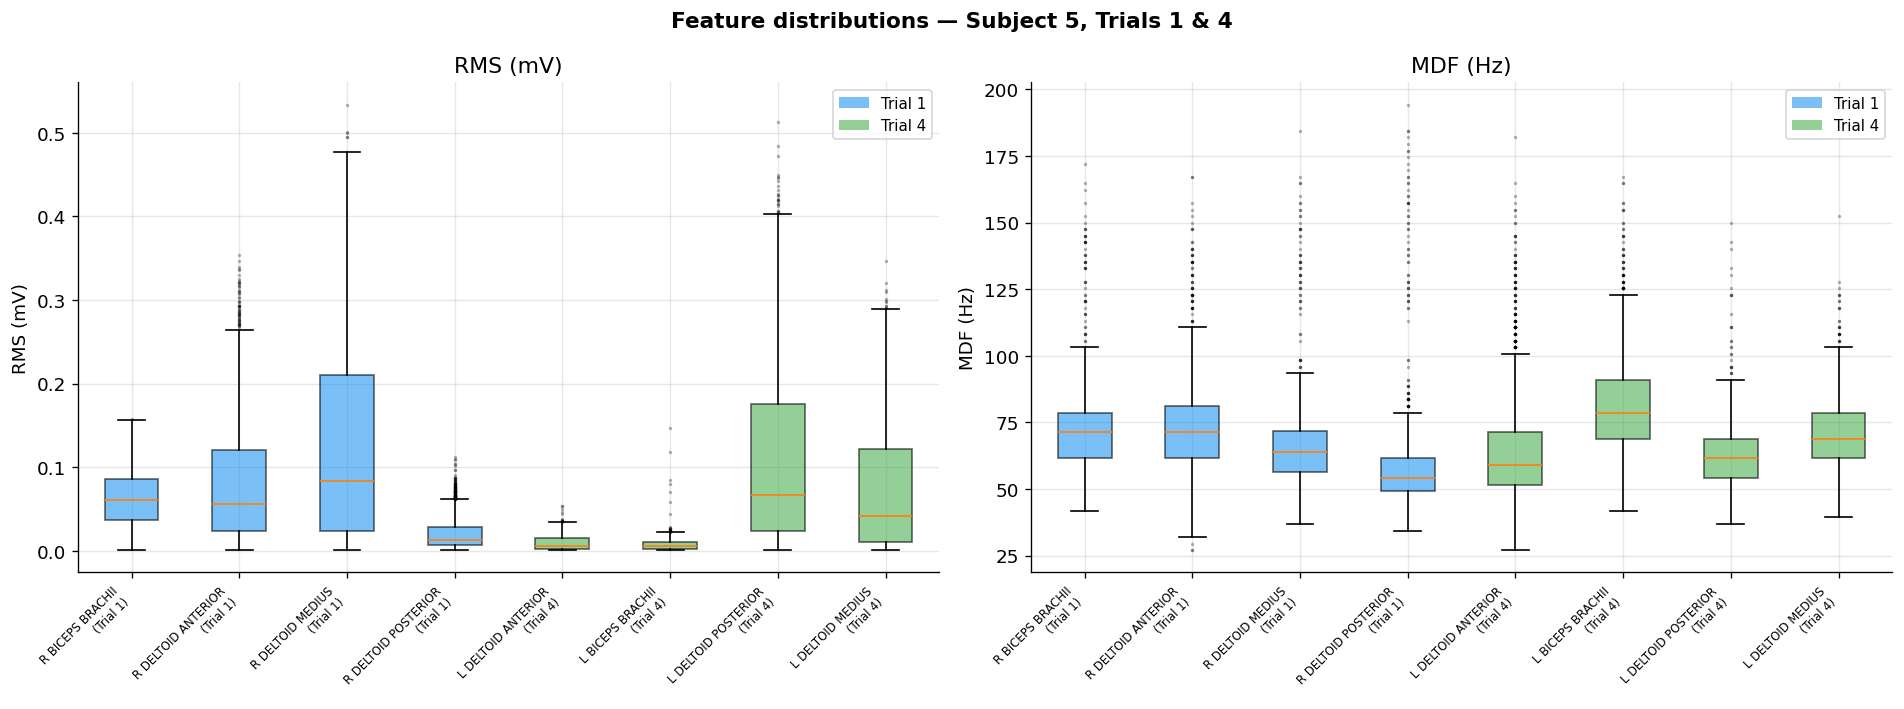

In [ ]:
# Box-plots: RMS and MDF distributions per channel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature distributions — Subject 5, Trials 1 & 4',
             fontsize=13, fontweight='bold')

all_features = {'Trial 1': feat1, 'Trial 4': feat4}
trial_colors = {'Trial 1': '#2196F3', 'Trial 4': '#4CAF50'}

for feat_idx, feat_name in enumerate(['rms', 'mdf']):
    ax = axes[feat_idx]
    data_to_plot = []
    tick_labels  = []

    for trial_name, features in all_features.items():
        for ch, d in features.items():
            vals = d[feat_name]
            data_to_plot.append(vals[np.isfinite(vals)])
            tick_labels.append(f"{ch.split(':')[0]}\n({trial_name})")

    bp = ax.boxplot(data_to_plot, patch_artist=True, showfliers=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))

    # Colour boxes by trial
    for i, patch in enumerate(bp['boxes']):
        trial = 'Trial 1' if i < 4 else 'Trial 4'
        patch.set_facecolor(trial_colors[trial])
        patch.set_alpha(0.6)

    ax.set_xticks(range(1, len(tick_labels) + 1))
    ax.set_xticklabels(tick_labels, fontsize=7, rotation=45, ha='right')
    ylabel = 'RMS (mV)' if feat_name == 'rms' else 'MDF (Hz)'
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

    # Legend
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=c, alpha=0.6, label=t)
                      for t, c in trial_colors.items()]
    ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.show()

## Signal stationarity check, rolling mean & std

For a stationary signal, the rolling mean should hover near zero and the rolling standard deviation should be relatively stable over time.  
Trends in either metric hint at **non-stationarity** (e.g., increasing fatigue, electrode gel drying).

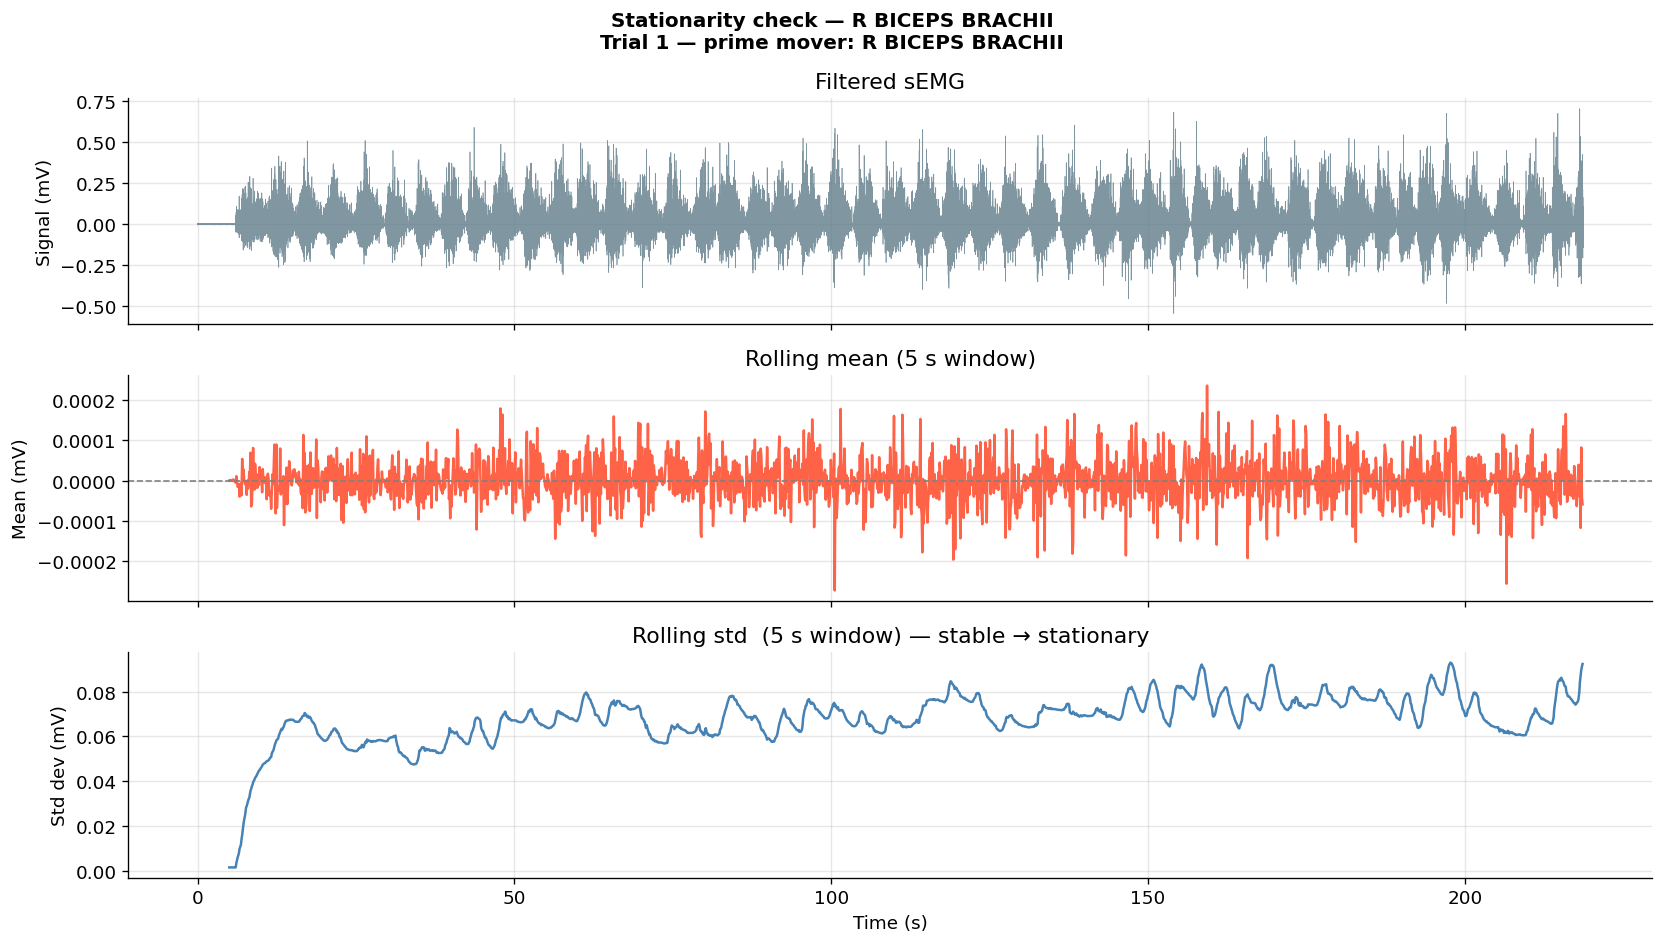

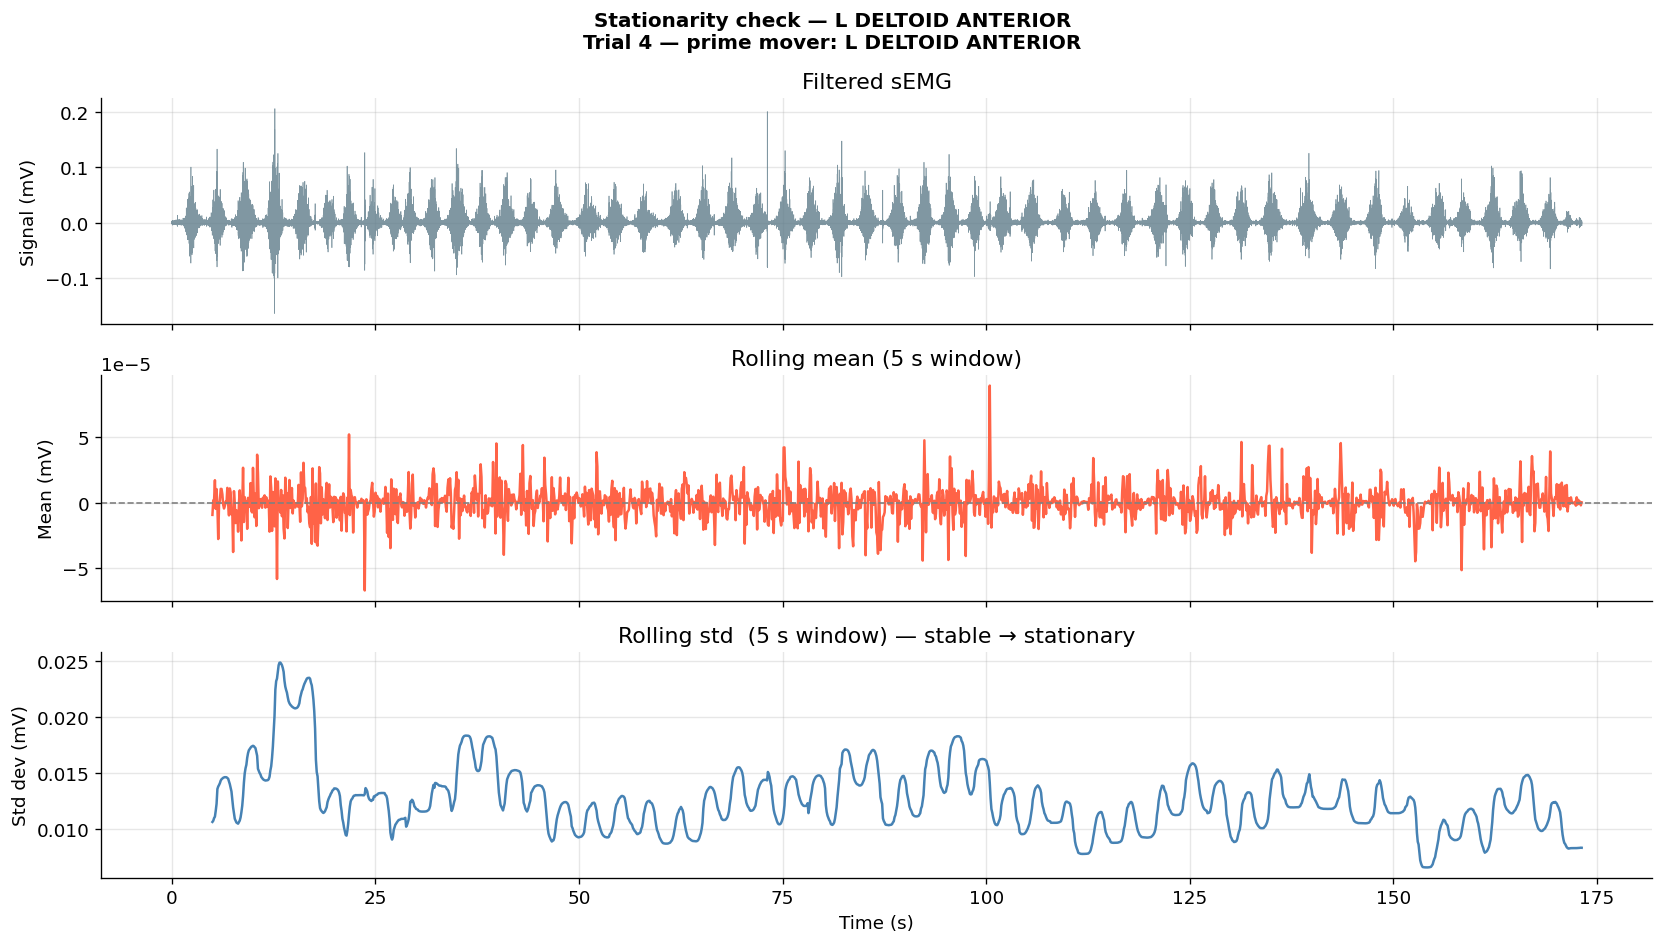

In [ ]:
def plot_stationarity(trial_filt, trial_name, channel_key=None, roll_sec=5.0):
    """
    Plot rolling mean and rolling std for a single channel over the full trial.
    Roll window = roll_sec seconds of data.
    """
    time = trial_filt['time']

    # Pick the first channel by default
    if channel_key is None:
        channel_key = list(trial_filt['channels'].keys())[0]

    sig = trial_filt['channels'][channel_key] * 1000  # → mV

    roll_n   = int(roll_sec * FS)  # samples in the rolling window
    n        = len(sig)

    # Compute rolling stats
    roll_mean = [sig[max(0, i-roll_n):i].mean() for i in range(roll_n, n, 128)]
    roll_std  = [sig[max(0, i-roll_n):i].std()  for i in range(roll_n, n, 128)]
    roll_time = time[list(range(roll_n, n, 128))]

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Stationarity check — {channel_key.split(":")[0]}\n{trial_name}',
                 fontsize=12, fontweight='bold')

    axes[0].plot(time, sig, linewidth=0.4, color='#607D8B', alpha=0.8)
    axes[0].set_ylabel('Signal (mV)')
    axes[0].set_title('Filtered sEMG')

    axes[1].plot(roll_time, roll_mean, color='tomato', linewidth=1.5)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_ylabel('Mean (mV)')
    axes[1].set_title(f'Rolling mean ({roll_sec:.0f} s window)')

    axes[2].plot(roll_time, roll_std, color='steelblue', linewidth=1.5)
    axes[2].set_ylabel('Std dev (mV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_title(f'Rolling std  ({roll_sec:.0f} s window) — stable → stationary')

    plt.tight_layout()
    plt.show()


# Check the prime-mover channels
plot_stationarity(trial1_filt, 'Trial 1 — prime mover: R BICEPS BRACHII',
                  channel_key='R BICEPS BRACHII: EMG 1 [V]')
plot_stationarity(trial4_filt, 'Trial 4 — prime mover: L DELTOID ANTERIOR',
                  channel_key='L DELTOID ANTERIOR: EMG 3 [V]')

---

## Inter-channel correlation

High correlation between channels in the same trial may indicate:
- Synergistic muscle activation during the task
- Cross-talk (electrical signal leaking between nearby electrodes)

Compute Pearson correlation of the **RMS feature time-series** (not raw signals).

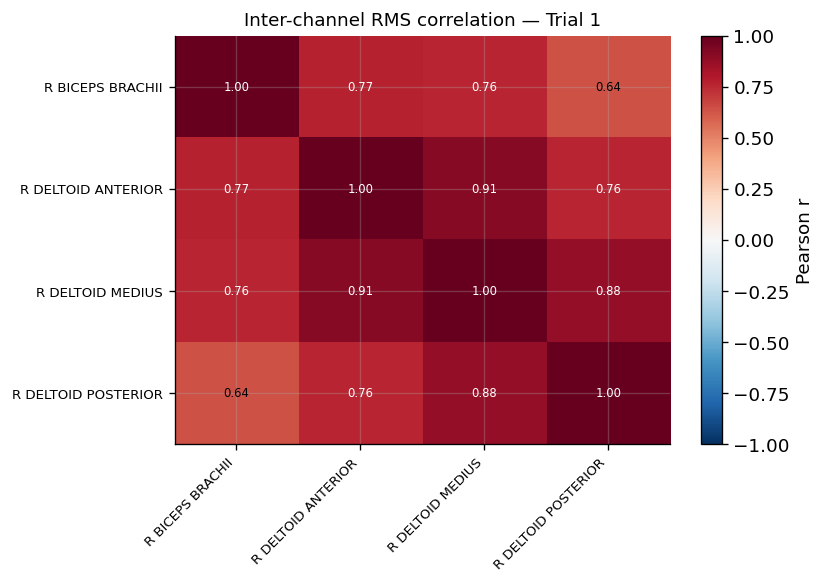

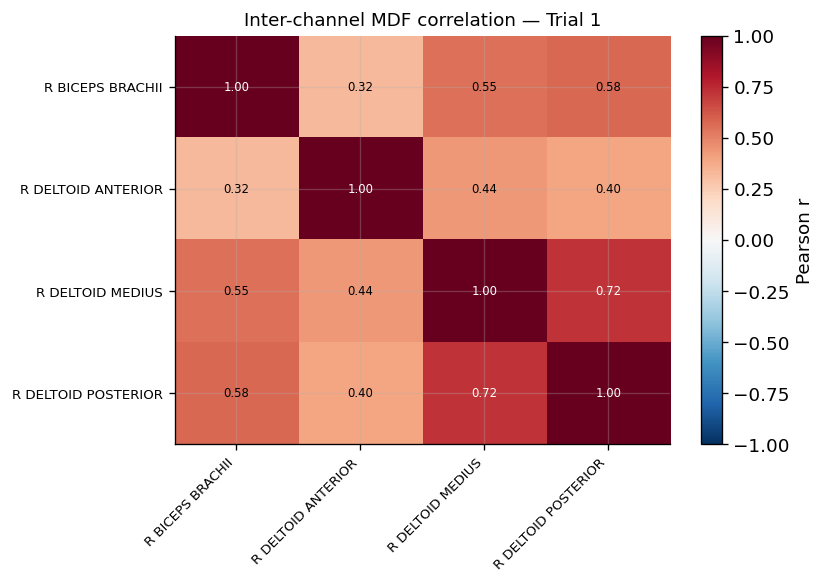

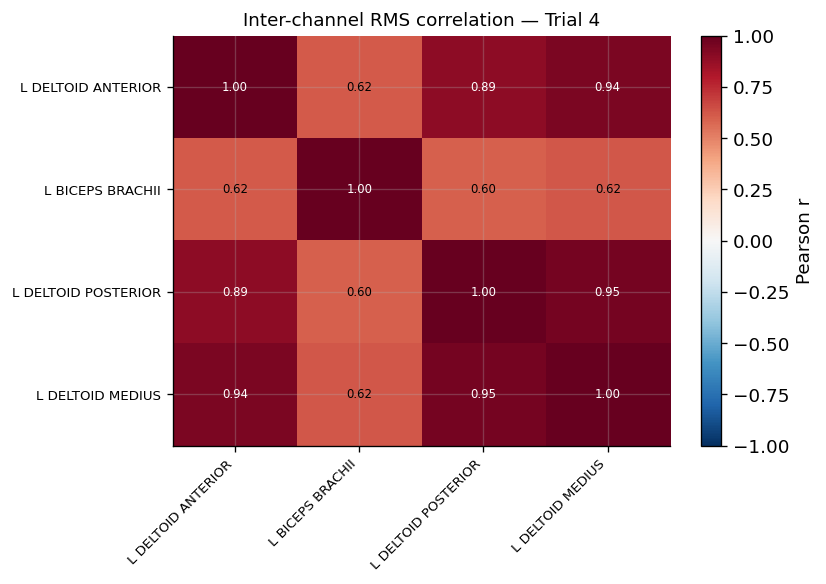

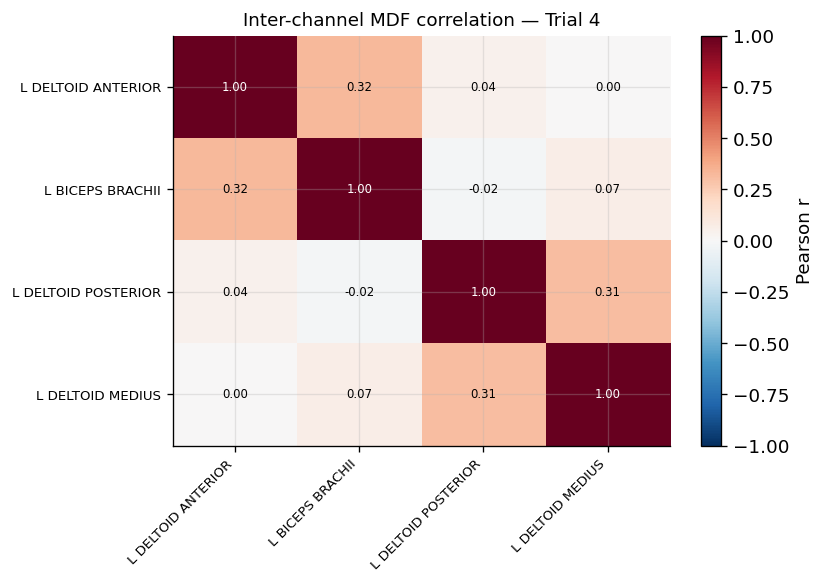

In [ ]:
import warnings
warnings.filterwarnings('ignore')

def correlation_heatmap(features, trial_name, feat_name='rms'):
    """
    Plot Pearson correlation matrix of the chosen feature across all channels.
    """
    short_names = [ch.split(':')[0] for ch in features.keys()]
    data_matrix = np.column_stack([features[ch][feat_name] for ch in features])

    corr = np.corrcoef(data_matrix.T)

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    plt.colorbar(im, ax=ax, label='Pearson r')

    ax.set_xticks(range(len(short_names)))
    ax.set_yticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)

    # Annotate with correlation values
    for i in range(len(short_names)):
        for j in range(len(short_names)):
            ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(corr[i, j]) < 0.7 else 'white')

    feat_label = 'RMS' if feat_name == 'rms' else 'MDF'
    ax.set_title(f'Inter-channel {feat_label} correlation — {trial_name}',
                 fontsize=11)
    plt.tight_layout()
    plt.show()


correlation_heatmap(feat1, 'Trial 1', feat_name='rms')
correlation_heatmap(feat1, 'Trial 1', feat_name='mdf')
correlation_heatmap(feat4, 'Trial 4', feat_name='rms')
correlation_heatmap(feat4, 'Trial 4', feat_name='mdf')

---

## 12. MVC normalisation baseline

The Maximum Voluntary Contraction (MVC) files contain recordings from each electrode during the subject's maximum contraction effort.  
We compute the **MVC RMS** and use it to express sEMG amplitude as **% MVC** — a normalised unit comparable across subjects.

In [ ]:
MVC_DIR = os.path.join(SUBJECT_DIR, 'MVC')

def load_mvc_rms(mvc_dir, muscle_tag):
    """
    Load the MVC CSV for a given muscle tag (e.g. 'R_BICEPS'),
    bandpass-filter it, and return its peak RMS (in mV).

    The MVC CSV has three columns: time, raw EMG, sliding-RMS (pre-computed).
    We recompute a clean RMS from our own bandpass-filtered signal.
    """
    mvc_file = [f for f in os.listdir(mvc_dir) if muscle_tag.upper() in f.upper()]
    if not mvc_file:
        return None, None

    path = os.path.join(mvc_dir, mvc_file[0])
    df   = pd.read_csv(path)

    # Column 0: time,  Column 1: raw EMG,  Column 2: pre-computed RMS
    raw_sig = df.iloc[:, 1].values

    # Bandpass filter
    raw_clean = np.where(np.isfinite(raw_sig), raw_sig, 0.0)
    filt_mvc  = scipy_signal.filtfilt(b_bp, a_bp, raw_clean)

    # Peak RMS over a 1-second sliding window — represents true MVC amplitude
    win = FS  # 1 second
    rms_vals = [
        np.sqrt(np.mean(filt_mvc[i:i+win]**2))
        for i in range(0, len(filt_mvc) - win, win // 2)
    ]
    peak_rms_mV = max(rms_vals) * 1000  # V → mV

    return peak_rms_mV, mvc_file[0]


# Load MVC for the 4 right-side muscles (Trial 1)
mvc_tags = {
    'R BICEPS BRACHII: EMG 1 [V]'     : 'R_BICEPS',
    'R DELTOID ANTERIOR: EMG 2 [V]'   : 'R_DELTOID_ANTERIOR',
    'R DELTOID MEDIUS: EMG 6 [V]'     : 'R_DELTOID_MEDIUS',
    'R DELTOID POSTERIOR: EMG 7 [V]'  : 'R_DELTOID_POSTERIOR',
}

print(f'MVC files found in {MVC_DIR}:')
mvc_rms = {}
for ch, tag in mvc_tags.items():
    rms_val, fname = load_mvc_rms(MVC_DIR, tag)
    mvc_rms[ch] = rms_val
    short = ch.split(':')[0]
    print(f'  {short:30s}  →  {fname}   |  Peak MVC RMS = {rms_val:.4f} mV')

MVC files found in C:\Users\Joebass\Documents\Physics-informed EMG Analysis\Artefact\Minho fatigue\sEMG_data\subject_5\MVC:
  R BICEPS BRACHII                →  subject_5_MVC_R_BICEPS.csv   |  Peak MVC RMS = 0.6507 mV
  R DELTOID ANTERIOR              →  subject_5_MVC_R_DELTOID_ANTERIOR.csv   |  Peak MVC RMS = 0.5997 mV
  R DELTOID MEDIUS                →  subject_5_MVC_R_DELTOID_MEDIUS.csv   |  Peak MVC RMS = 0.6748 mV
  R DELTOID POSTERIOR             →  subject_5_MVC_R_DELTOID_POSTERIOR.csv   |  Peak MVC RMS = 0.2478 mV


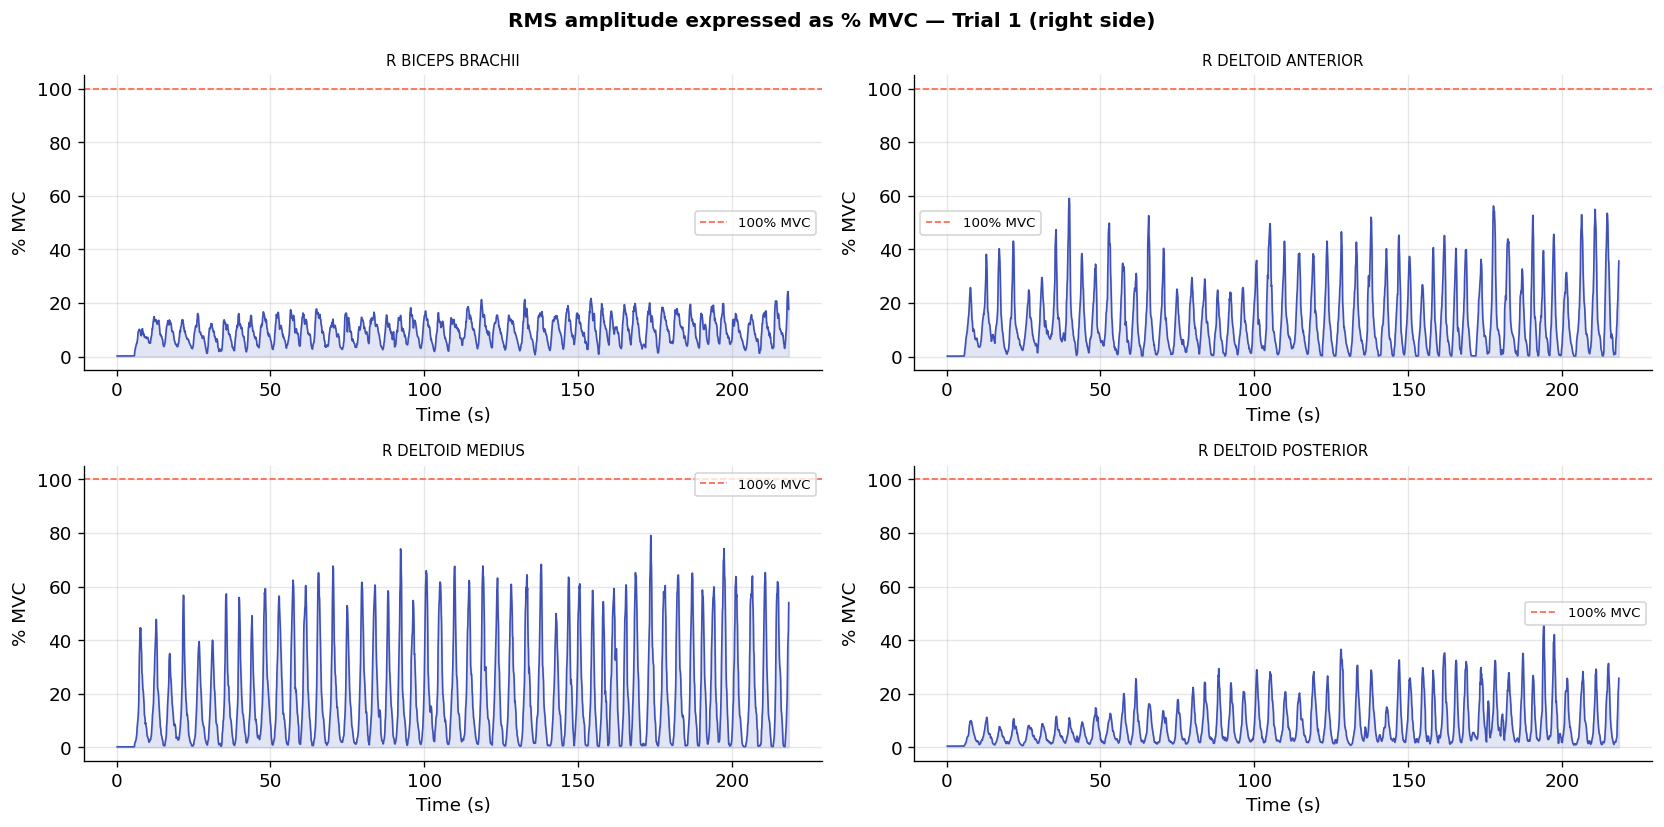

In [ ]:
# ── Express Trial 1 RMS as %MVC ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=False)
fig.suptitle('RMS amplitude expressed as % MVC — Trial 1 (right side)',
             fontsize=12, fontweight='bold')

for ax, (ch, d) in zip(axes.flat, feat1.items()):
    t   = d['time']
    rms = d['rms']  # mV
    mvc = mvc_rms.get(ch)

    if mvc and mvc > 0:
        pct_mvc = (rms / mvc) * 100
        ax.plot(t, pct_mvc, linewidth=1.0, color='#3F51B5')
        ax.fill_between(t, pct_mvc, alpha=0.15, color='#3F51B5')
        ax.axhline(100, color='tomato', linestyle='--', linewidth=1, label='100% MVC')
        ax.set_ylabel('% MVC')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No MVC file', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray')

    ax.set_title(ch.split(':')[0], fontsize=9)
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 13. Summary: data quality and preprocessing decisions

| Check | Result | Action taken |
|---|---|---|
| Missing values (NaN/Inf) | None found in trials | NaN/Inf guarded with replacement to 0 before filtering |
| Sampling rate | 1259 Hz — consistent across all channels | Confirmed from time-step analysis |
| DC offset / low-freq drift | Present in raw signals | Removed by 20 Hz high-pass stage of bandpass filter |
| High-freq noise | Present above physiological band | Removed by 450 Hz low-pass stage |
| Amplitude outliers | Within ±3σ range for all channels | No clipping required |
| Stationarity | Rolling std shows expected non-stationarity (muscle fatigue develops) | Noted — this is the signal of interest |
| Filter phase distortion | Could distort temporal analysis | Used `filtfilt` (zero-phase) to eliminate |

### Important observation
- **RMS** varies substantially across the trial, reflecting changes in muscle activation level.  
- **MDF** fluctuates around 100–150 Hz — a downward trend over time would be a hallmark of fatigue.  
- The right-side muscles (Trial 1) show higher activation levels compared to left-side muscles (Trial 2), which may reflect Subject 5's dominant hand side.
- All channels pass basic quality checks — the dataset appears clean and suitable for further modelling.